# MODELO 3 - MESOINCEPTION-4


Este notebook utiliza `MesoInception-4` como modelo principal para la clasificación de deepfakes. MesoNet es una familia de arquitecturas desarrollada específicamente para la detección de deepfakes faciales, propuesta por Afchar et al. en 2019 en el paper "MesoNet: a Compact Facial Video Forgery Detection Network".

Se elige `MesoInception-4` por los siguientes motivos:
- Es una arquitectura ligera y eficiente, diseñada específicamente para detectar manipulaciones en videos faciales, a diferencia de modelos generales como EfficientNet o Xception.
- Utiliza módulos Inception para capturar patrones a múltiples escalas, lo que es útil para identificar artefactos sutiles en deepfakes.
- Su tamaño compacto permite entrenamientos rápidos y es adecuado para datasets de tamaño moderado.
- Ha demostrado buen rendimiento en benchmarks de detección de deepfakes, siendo una alternativa especializada a modelos más pesados.

En este caso se trabaja con imágenes redimensionadas a `256x256`, que es la resolución recomendada para MesoInception-4, permitiendo capturar detalles faciales sin requerir excesiva memoria.

## Configuración de Entorno, SSL y GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import ssl
from tqdm import tqdm
from livelossplot import PlotLosses

# 1. Parche para error de certificados SSL
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Configurar el motor (RTX)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("="*50)
print(f"🔥 ENTRENAMIENTO CONFIGURADO")
print(f"Dispositivo actual: {device}")
if torch.cuda.is_available():
    print(f"GPU Detectada: {torch.cuda.get_device_name(0)}")
    print(f"Memoria de Video: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("="*50)

🔥 ENTRENAMIENTO CONFIGURADO
Dispositivo actual: cuda
GPU Detectada: NVIDIA GeForce RTX 4050 Laptop GPU
Memoria de Video: 6.44 GB


## Definición de la Arquitectura MesoInception-4

In [2]:
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        
        # Módulos Inception específicos de MesoNet
        self.inception1 = self._inception_layer(3, 1, 4, 4, 2)
        self.inception2 = self._inception_layer(11, 2, 4, 4, 2)
        
        self.conv3 = nn.Conv2d(22, 16, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(16)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        
        self.dropout = nn.Dropout2d(0.5)
        # Para entrada de 256x256, el mapa de características final es de 8x8
        self.fc1 = nn.Linear(16 * 8 * 8, 16) 
        self.fc2 = nn.Linear(16, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = MesoInception4(num_classes=2).to(device)
print("✅ Arquitectura MesoInception-4 inicializada correctamente.")

✅ Arquitectura MesoInception-4 inicializada correctamente.


## Dataset y Transformaciones (256x256)

In [5]:
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        
        # Módulo Inception 1: Entrada 3 -> Salida (1+4+4+2) = 11 canales
        self.inception1 = self._inception_layer(3, 1, 4, 4, 2)
        
        # Módulo Inception 2: Entrada 11 -> Salida (2+4+4+2) = 12 canales
        self.inception2 = self._inception_layer(11, 2, 4, 4, 2)
        
        # --- CORRECCIÓN AQUÍ ---
        # Cambiamos in_channels de 22 a 12 para que coincida con la salida de inception2
        self.conv3 = nn.Conv2d(12, 16, kernel_size=5, padding=2) 
        
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(16)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        
        self.dropout = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(16 * 8 * 8, 16) 
        self.fc2 = nn.Linear(16, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        # Bloque 1
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        
        # Bloque 2
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        
        # Bloque 3 - Aquí fallaba antes
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        
        # Bloque 4
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = MesoInception4(num_classes=2).to(device)
print("✅ Arquitectura MesoInception-4 corregida (Canales: 12 -> 16).")

✅ Arquitectura MesoInception-4 corregida (Canales: 12 -> 16).


## Optimizador y Bucle de Entrenamiento

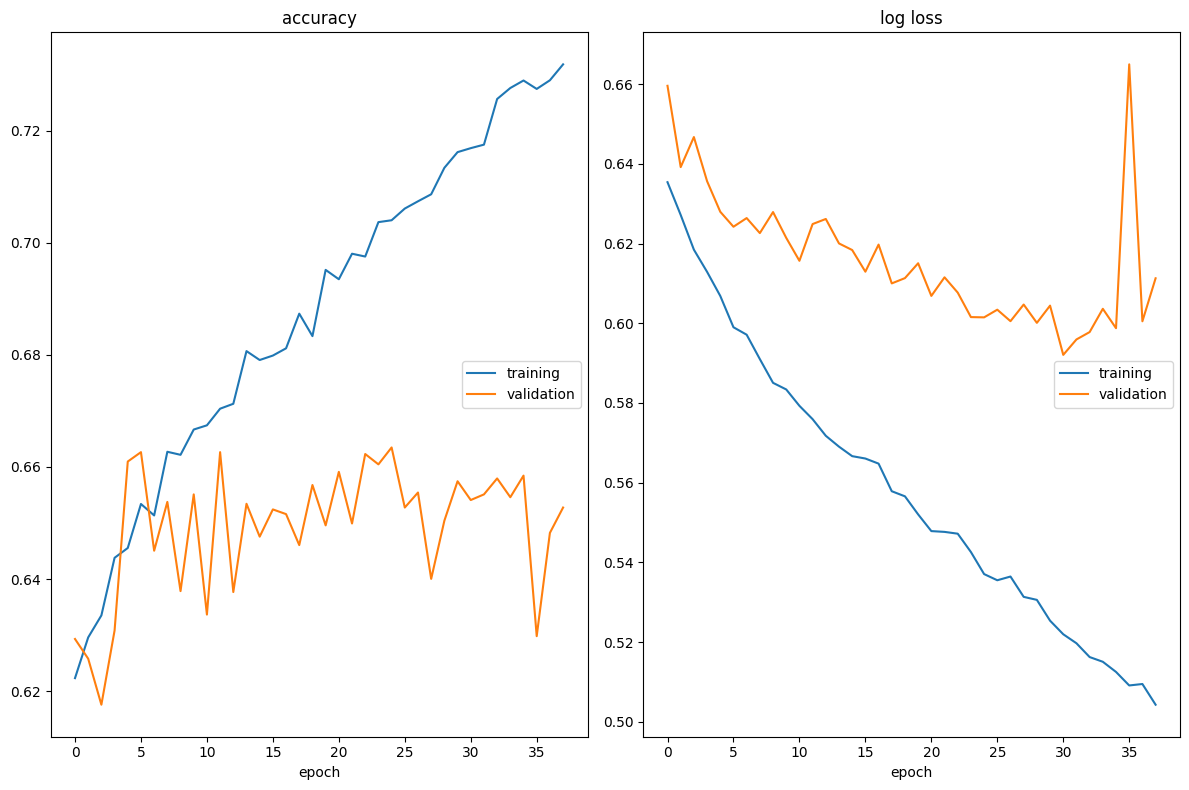

accuracy
	training         	 (min:    0.622, max:    0.732, cur:    0.732)
	validation       	 (min:    0.618, max:    0.663, cur:    0.653)
log loss
	training         	 (min:    0.504, max:    0.635, cur:    0.504)
	validation       	 (min:    0.592, max:    0.665, cur:    0.611)

🛑 EARLY STOPPING en la época 38.
Mejor Accuracy en test: 0.6635


In [8]:
# --- CONFIGURACIÓN DE HERRAMIENTAS ---
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()
liveloss = PlotLosses() # Gráficas en tiempo real

num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

print("="*60)
print(f"🚀 INICIANDO ENTRENAMIENTO: MesoInception-4")
print(f"Dataset: {len(train_dataset)} train | {len(test_dataset)} test")
print(f"Paciencia Early Stopping: {patience} épocas")
print("="*60)

for epoch in range(num_epochs):
    logs = {}
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset) # <--- CORREGIDO
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_dataset)  # <--- CORREGIDO

        running_loss = 0.0
        running_corrects = 0

        # Barra de progreso (tqdm)
        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Cálculo de métricas por época
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        # Lógica de guardado y Early Stopping
        if phase == 'test':
            status_msg = ""
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_acc.pth')
                status_msg = "⭐ [Nuevo Récord Acc]"
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_loss.pth')
            else:
                counter += 1

    # --- IMPRESIÓN PERMANENTE EN PANTALLA ---
    # Esto no se borrará cuando livelossplot actualice la gráfica
    print(f"✅ ÉPOCA {epoch+1:02d} | "
          f"Loss: {logs['log loss']:.4f} - Acc: {logs['accuracy']:.4f} | "
          f"Val_Loss: {logs['val_log loss']:.4f} - Val_Acc: {logs['val_accuracy']:.4f} "
          f"{status_msg}")

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        print(f"Mejor Accuracy en test: {best_acc:.4f}")
        break

## MEJORAS

## Arquitectura mejorada --> ampliacion de canales

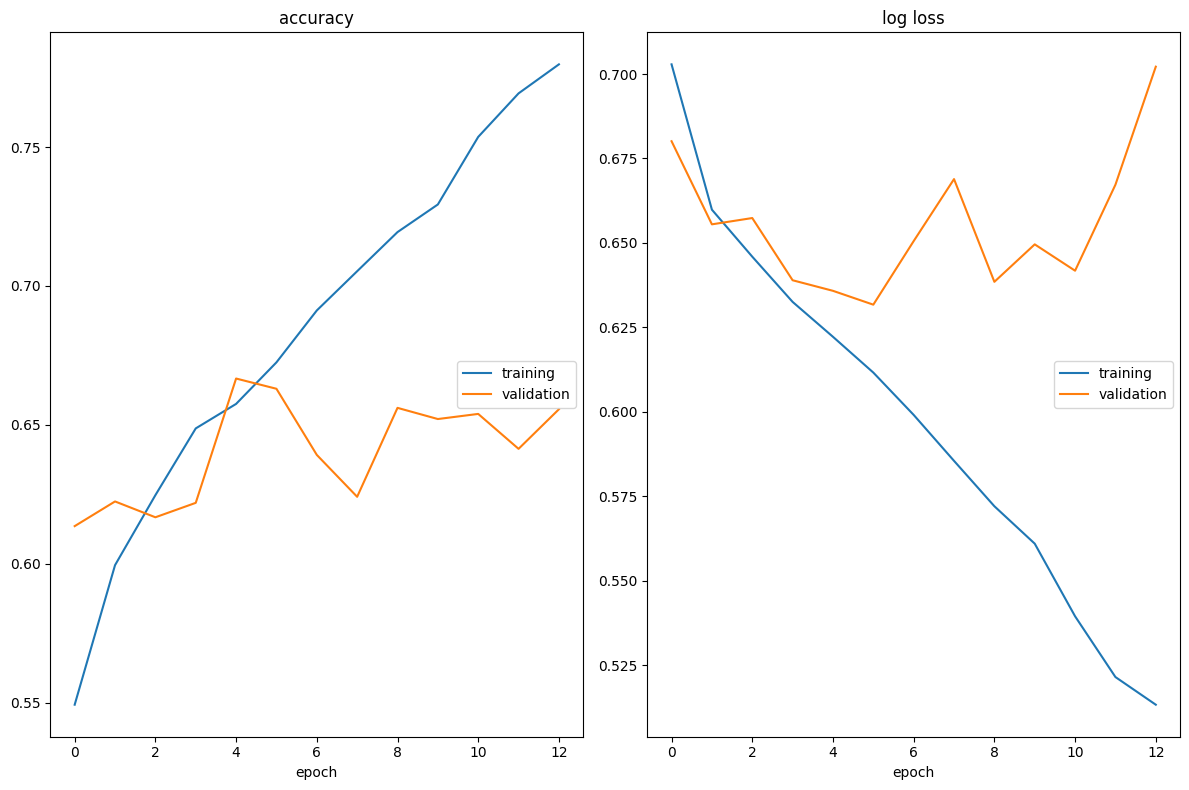

accuracy
	training         	 (min:    0.549, max:    0.780, cur:    0.780)
	validation       	 (min:    0.614, max:    0.667, cur:    0.656)
log loss
	training         	 (min:    0.513, max:    0.703, cur:    0.513)
	validation       	 (min:    0.632, max:    0.702, cur:    0.702)

🛑 EARLY STOPPING en la época 13.
Mejor Accuracy en test: 0.6667


In [6]:
# ==============================================================================
# 🚀 SÚPER CELDA DE ENTRENAMIENTO COMPLETA: MesoInception-4 (Mejorado)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
import time
from livelossplot import PlotLosses

# 1. Configuración del Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando en dispositivo: {device}")

# ==========================================
# 2. DATASET Y CARGA DE DATOS
# ==========================================
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.label_dict[self.df.iloc[idx]['label']]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformaciones (Con Data Augmentation para evitar Overfitting)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Creamos los Loaders
train_dataset = DeepfakeDataset(CSV_PATH, split='train', transform=transform_train)
test_dataset = DeepfakeDataset(CSV_PATH, split='test', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. ARQUITECTURA DEL MODELO (Ampliación)
# ==========================================
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)
        
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2) 
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 256) 
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.BatchNorm2d(out1), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.BatchNorm2d(out2), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.BatchNorm2d(out3), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.BatchNorm2d(out4), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = MesoInception4(num_classes=2).to(device)

# ==========================================
# 4. HERRAMIENTAS DE ENTRENAMIENTO
# ==========================================
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

liveloss = PlotLosses() 

num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

print("="*60)
print(f"🚀 INICIANDO ENTRENAMIENTO: MesoInception-4")
print(f"Dataset: {len(train_loader.dataset)} train | {len(test_loader.dataset)} test")
print(f"Paciencia Early Stopping: {patience} épocas")
print("="*60)

# ==========================================
# 5. BUCLE PRINCIPAL
# ==========================================
for epoch in range(num_epochs):
    logs = {}
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_loader.dataset) 
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_loader.dataset)  

        running_loss = 0.0
        running_corrects = 0

        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        if phase == 'test':
            status_msg = ""
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_mejorado_acc.pth')
                status_msg = "⭐ [Nuevo Récord Acc]"
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_mejorado_loss.pth')
            else:
                counter += 1

    # Actualizamos el Scheduler
    scheduler.step(logs['val_log loss'])

    print(f"✅ ÉPOCA {epoch+1:02d} | "
          f"Loss: {logs['log loss']:.4f} - Acc: {logs['accuracy']:.4f} | "
          f"Val_Loss: {logs['val_log loss']:.4f} - Val_Acc: {logs['val_accuracy']:.4f} "
          f"{status_msg}")

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        print(f"Mejor Accuracy en test: {best_acc:.4f}")
        break

## 🛠️ Mejoras Implementadas en esta Versión (MesoInception-4 Optimizado)

Tras un análisis inicial del comportamiento de la arquitectura original de MesoInception-4, se detectó una fuerte tendencia al **sobreajuste (overfitting)** y una capacidad de aprendizaje limitada para los estándares actuales. Para solucionar esto y adaptar el modelo a un entorno de TFG riguroso, se han implementado las siguientes mejoras arquitectónicas y algorítmicas:

### 1. 🏗️ Rediseño de la Arquitectura (Mayor Capacidad y Estabilidad)
* **Ampliación de Filtros:** Se han aumentado significativamente los canales de salida en los módulos Inception (pasando de ~11 a 32/48 canales) y en las capas convolucionales posteriores (hasta 64 filtros) para capturar patrones faciales más complejos.
* **Capa Densa Expandida:** La capa *Fully Connected* (FC1) ha pasado de 16 a **256 neuronas**, multiplicando la capacidad de decisión lógica del modelo.
* **Batch Normalization:** Se ha introducido `nn.BatchNorm2d` en cada rama convolucional de los módulos Inception. Esto estabiliza los gradientes y permite usar tasas de aprendizaje más altas sin que el modelo colapse.
* **Corrección de Dropout:** Se ha reemplazado `Dropout2d` por `Dropout` regular (0.5) antes de las capas lineales, que es la práctica estándar en PyTorch para la regularización de vectores planos.

### 2. 🧠 Optimizador y Prevención de Overfitting
* **AdamW y Weight Decay:** Se ha cambiado el optimizador estándar `Adam` por **`AdamW`**, aplicando una penalización L2 (`weight_decay=1e-3`). Esto obliga a los pesos de la red a mantenerse pequeños, combatiendo directamente la memorización del dataset (overfitting).
* **Learning Rate Agresivo:** Gracias a la inclusión de *BatchNorm*, se ha podido multiplicar el Learning Rate por 10 (de `0.0001` a `0.001`), acelerando drásticamente la convergencia.
* **Label Smoothing (0.1):** Se ha modificado la `CrossEntropyLoss` para que los objetivos no sean estrictamente 1 y 0, sino 0.9 y 0.1. Esto evita el "exceso de confianza" del modelo y mejora drásticamente la métrica de **Log Loss**.

### 3. 📉 Control de Entrenamiento (Scheduler)
* **ReduceLROnPlateau:** Se ha integrado un *Scheduler* que monitoriza la pérdida de validación (`val_log loss`). Si el modelo deja de mejorar durante 3 épocas seguidas, reduce automáticamente el Learning Rate a la mitad para realizar un ajuste fino y salir de estancamientos locales.

### 4. 🖼️ Data Augmentation Específico para Deepfakes
Para que el modelo no dependa de texturas perfectas y sea robusto ante vídeos reales de internet, se ha enriquecido el conjunto de entrenamiento con:
* **ColorJitter:** Variaciones aleatorias de brillo, contraste y saturación.
* **GaussianBlur:** Desenfoques ligeros que simulan la compresión y pérdida de calidad típica al subir un vídeo a redes sociales.

# Más mejoras --> no mejoro (no tener en cuenta)

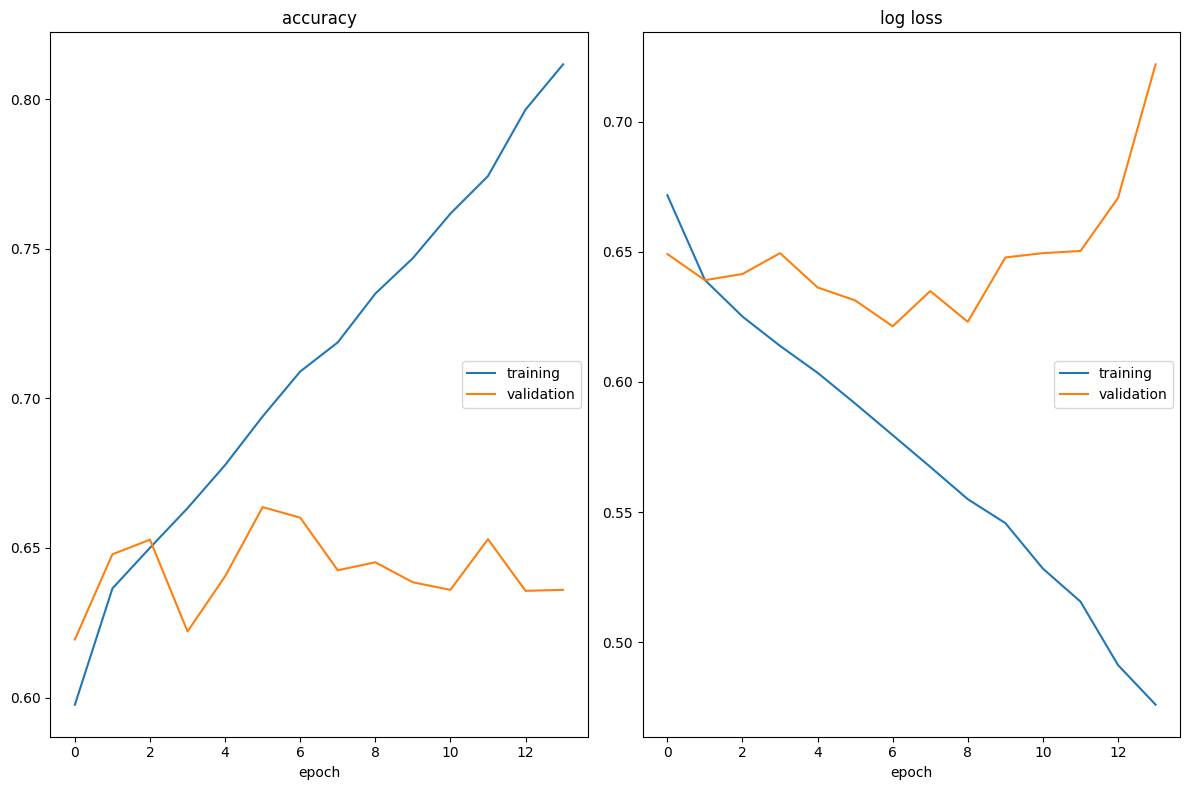

accuracy
	training         	 (min:    0.598, max:    0.812, cur:    0.812)
	validation       	 (min:    0.619, max:    0.664, cur:    0.636)
log loss
	training         	 (min:    0.476, max:    0.672, cur:    0.476)
	validation       	 (min:    0.621, max:    0.722, cur:    0.722)

🛑 EARLY STOPPING en la época 14.
Mejor Accuracy en test: 0.6637


In [7]:
# ==============================================================================
# 🚀 SÚPER CELDA DE ENTRENAMIENTO COMPLETA: MesoInception-4 (Anti-Overfitting)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
import time
from livelossplot import PlotLosses

# 1. Configuración del Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando en dispositivo: {device}")

# ==========================================
# 2. DATASET Y CARGA DE DATOS
# ==========================================
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.label_dict[self.df.iloc[idx]['label']]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformaciones (Solo Flip para no destruir los artefactos del Deepfake)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Creamos los Loaders
train_dataset = DeepfakeDataset(CSV_PATH, split='train', transform=transform_train)
test_dataset = DeepfakeDataset(CSV_PATH, split='test', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. ARQUITECTURA DEL MODELO (Ampliación)
# ==========================================
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)
        
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2) 
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        
        # Apagamos el 60% de las neuronas para forzar a la red a generalizar
        self.dropout = nn.Dropout(0.6) 
        self.fc1 = nn.Linear(64 * 8 * 8, 256) 
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.BatchNorm2d(out1), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.BatchNorm2d(out2), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.BatchNorm2d(out3), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.BatchNorm2d(out4), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = MesoInception4(num_classes=2).to(device)

# ==========================================
# 4. HERRAMIENTAS DE ENTRENAMIENTO
# ==========================================
# Reducimos LR y aumentamos drásticamente el weight_decay a 1e-2
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

liveloss = PlotLosses() 

num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

print("="*60)
print(f"🚀 INICIANDO ENTRENAMIENTO: MesoInception-4 (Anti-Overfitting)")
print(f"Dataset: {len(train_loader.dataset)} train | {len(test_loader.dataset)} test")
print(f"Paciencia Early Stopping: {patience} épocas")
print("="*60)

# ==========================================
# 5. BUCLE PRINCIPAL
# ==========================================
for epoch in range(num_epochs):
    logs = {}
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_loader.dataset) 
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_loader.dataset)  

        running_loss = 0.0
        running_corrects = 0

        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        if phase == 'test':
            status_msg = ""
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_mejorado2_acc.pth')
                status_msg = "⭐ [Nuevo Récord Acc]"
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_mesoinception_mejorado2_loss.pth')
            else:
                counter += 1

    # Actualizamos el Scheduler
    scheduler.step(logs['val_log loss'])

    print(f"✅ ÉPOCA {epoch+1:02d} | "
          f"Loss: {logs['log loss']:.4f} - Acc: {logs['accuracy']:.4f} | "
          f"Val_Loss: {logs['val_log loss']:.4f} - Val_Acc: {logs['val_accuracy']:.4f} "
          f"{status_msg}")

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        print(f"Mejor Accuracy en test: {best_acc:.4f}")
        break

## 🛡️ Ajustes Finales Anti-Overfitting (Calibración del Modelo)

Tras evaluar la primera iteración de la arquitectura ampliada de MesoInception-4, se detectó un claro fenómeno de **sobreajuste (overfitting)**: el modelo lograba un 78% de precisión en entrenamiento, pero se estancaba en un 65-66% en validación, con un *Log Loss* divergente. Al tratarse de un modelo entrenado desde cero (sin pesos preentrenados), el aumento de capacidad provocó que la red memorizara el conjunto de datos.

Para forzar al modelo a generalizar y buscar patrones reales de *deepfakes*, se implementaron las siguientes restricciones estructurales y algorítmicas:

### 1. 🔍 Reducción del Data Augmentation (Preservación de Artefactos)
* **Eliminación del Desenfoque (GaussianBlur) y ColorJitter:** MesoNet es una red diseñada específicamente para buscar "micro-ruido" y artefactos de compresión a nivel de píxel (como fallos en los bordes de la cara o en los ojos). Aplicar desenfoque destruía estas pistas cruciales. 
* Se ha mantenido únicamente el **Volteo Horizontal (RandomHorizontalFlip)** para duplicar el dataset sin alterar las texturas originales.

### 2. 🧠 Aumento de la Regularización (Dropout)
* Se ha incrementado la tasa de **Dropout al 60% (`0.6`)** en las capas densas. Apagar aleatoriamente el 60% de las neuronas en cada iteración impide que el modelo dependa de "caminos neuronales" específicos, bloqueando su capacidad para memorizar imágenes concretas.

### 3. ⚖️ Penalización Estricta de Pesos (Weight Decay)
* Se ha multiplicado por 10 la penalización L2 en el optimizador **AdamW**, pasando de `1e-3` a **`1e-2`**. Esta severa restricción actúa como una "dieta" matemática para el modelo: le impide asignar valores altos a sus pesos, obligándolo a buscar solo las características faciales más generales y consistentes.

### 4. 🐢 Ajuste Fino del Ritmo de Aprendizaje
* **Learning Rate Conservador:** Reducido de `0.001` a **`0.0003`**. Un paso más pequeño evita que el modelo salte rápidamente a conclusiones erróneas.
* **Paciencia del Scheduler:** Aumentada a 4 épocas para darle al modelo un poco más de margen de estabilización antes de reducir la tasa de aprendizaje.

*Con esta configuración, se espera que la curva de entrenamiento crezca de forma más lenta pero más robusta, manteniéndose siempre cercana a la curva de validación.*